# Step 6: PieceLog-PatchTST — Physics-Informed Concentration Prediction

This notebook trains a PatchTST encoder that predicts **piece-log parameters** instead of raw concentration,
then evaluates the differentiable parametric model at the prediction time.

**Key idea:** The EDA notebook showed that P(t) follows a 3-phase parametric model:
- Phase 1: P = 0 (delay)
- Phase 2: Logistic growth with lag
- Phase 3: Linear decline

**Architecture:** PatchTST encoder → 7 constrained parameters → differentiable piece-log → P̂(T+D)

**Loss:** MSE(P̂, P_true) + α·MSE(θ̂, θ_fitted)

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

from src.data_loader import load_batches
from src.domain_splits import get_control_mode_split
from src.piecelog_model import (
    piecelog_numpy, fit_piecelog, fit_all_batches, PARAM_NAMES,
)
from src.piecelog_patchtst import PieceLogPatchTST, create_piecelog_model
from src.piecelog_dataset import create_piecelog_dataloaders, compute_param_stats
from src.train_piecelog import (
    train_and_evaluate_piecelog, evaluate_piecelog,
    make_stepwise_alpha_schedule,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## 1. Load Data & Domain Split

In [2]:
batches = load_batches()
split = get_control_mode_split("1c")

source_ids = split["source"]  # Batches 1-30 (recipe)
target_ids = split["target"]  # Batches 61-90 (APC)

print(f"Source batches: {len(source_ids)}")
print(f"Target batches: {len(target_ids)}")
print(f"Total batches loaded: {len(batches)}")

Source batches: 60
Target batches: 30
Total batches loaded: 100


## 2. Pre-Fit Piece-Log Parameters

Fit the 7-parameter piece-log model to all 90 non-fault batches.

In [3]:
# Fit all batches
fitted_params_df = fit_all_batches(batches, exclude_faults=True)

# Save for reproducibility
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)
fitted_params_df.to_csv(output_dir / "fitted_piecelog_params.csv", index=False)

print(f"Fitted {len(fitted_params_df)} batches")
print(f"\nR² statistics:")
print(f"  Mean:   {fitted_params_df['r_squared'].mean():.6f}")
print(f"  Median: {fitted_params_df['r_squared'].median():.6f}")
print(f"  Min:    {fitted_params_df['r_squared'].min():.6f}")
print(f"  Max:    {fitted_params_df['r_squared'].max():.6f}")

fitted_params_df.describe()

Fitted 90 batches

R² statistics:
  Mean:   0.999647
  Median: 0.999751
  Min:    0.996718
  Max:    0.999939


,batch_id,K,r,t0,lam,t_lag,t_break,slope,r_squared
count,90.000000,90.000000,90.000000,9.000000e+01,90.000000,90.000000,90.000000,9.000000e+01,90.000000
mean,45.500000,37.064513,0.021367,3.789035e+01,0.022920,25.834098,196.479953,4.826353e-02,0.999647
std,26.124701,9.024119,0.009317,4.099052e+01,0.022882,1.688916,30.283830,6.443983e-02,0.000423
min,1.000000,13.885244,0.004958,4.752243e-36,0.004703,21.713797,126.000000,6.042484e-66,0.996718
25%,23.250000,31.716960,0.015228,5.145676e-06,0.008558,24.684612,178.688209,2.240253e-29,0.999641
50%,45.500000,36.168814,0.019855,2.196138e+01,0.011652,26.004490,206.376363,2.140086e-12,0.999751
75%,67.750000,40.095541,0.026801,7.221985e+01,0.031615,26.964077,215.401385,1.098574e-01,0.999854
max,90.000000,83.800048,0.054360,2.300000e+02,0.129343,29.448737,290.000000,1.969917e-01,0.999939


### 2.1 Verify Fits — R² Distribution

/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_33732/2706690267.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([source_r2, target_r2], labels=["Source", "Target"])


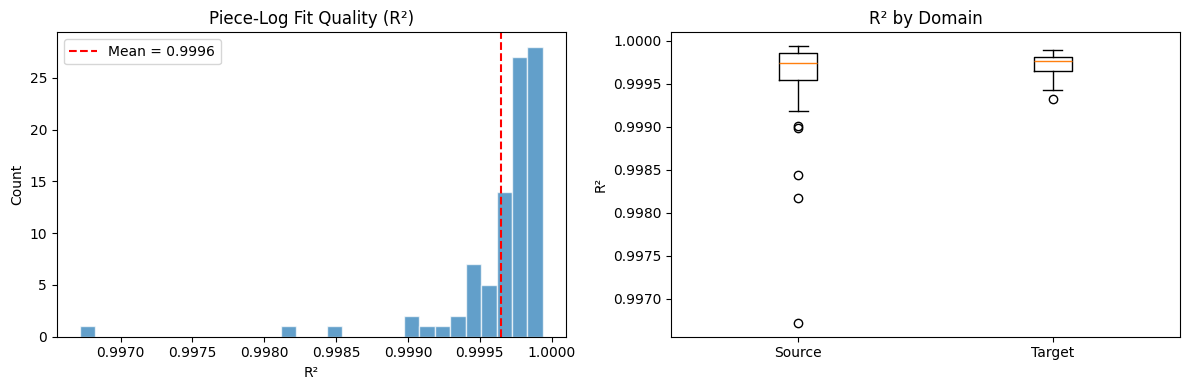

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² histogram
axes[0].hist(fitted_params_df["r_squared"], bins=30, edgecolor="white", alpha=0.7)
axes[0].axvline(fitted_params_df["r_squared"].mean(), color="red", linestyle="--",
                label=f"Mean = {fitted_params_df['r_squared'].mean():.4f}")
axes[0].set_xlabel("R²")
axes[0].set_ylabel("Count")
axes[0].set_title("Piece-Log Fit Quality (R²)")
axes[0].legend()

# R² by domain
source_r2 = fitted_params_df[fitted_params_df["batch_id"].isin(source_ids)]["r_squared"]
target_r2 = fitted_params_df[fitted_params_df["batch_id"].isin(target_ids)]["r_squared"]
axes[1].boxplot([source_r2, target_r2], labels=["Source", "Target"])
axes[1].set_ylabel("R²")
axes[1].set_title("R² by Domain")

plt.tight_layout()
plt.show()

### 2.2 Example Fitted Curves

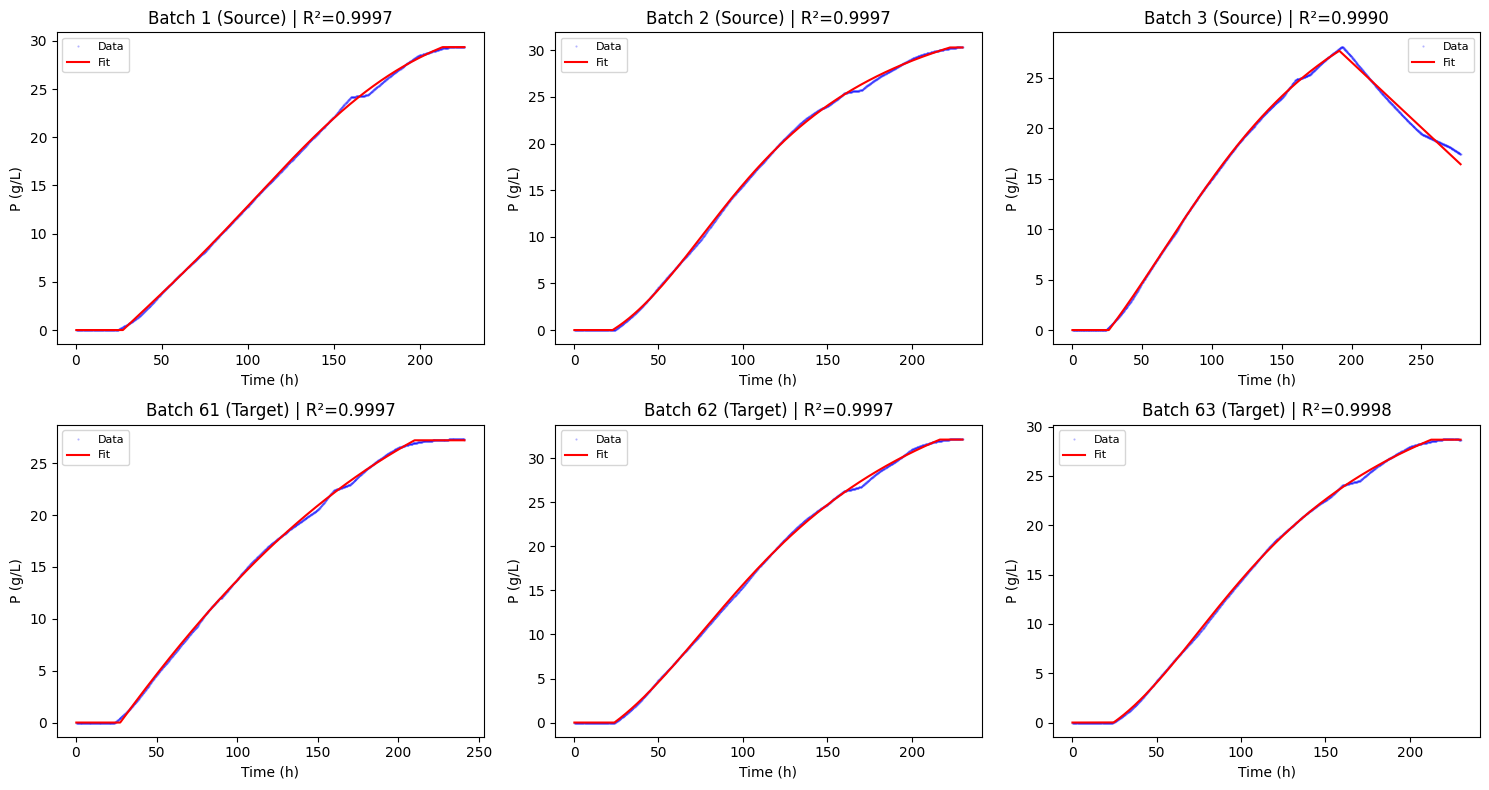

In [5]:
# Show 6 example fits (3 source, 3 target)
example_ids = list(source_ids[:3]) + list(target_ids[:3])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, bid in zip(axes.flat, example_ids):
    df = batches[bid]
    t = df["time"].values
    y = df["P"].values

    row = fitted_params_df[fitted_params_df["batch_id"] == bid].iloc[0]
    params = [row[p] for p in PARAM_NAMES]
    y_fit = piecelog_numpy(t, *params)

    ax.plot(t, y, "b.", alpha=0.3, markersize=1, label="Data")
    ax.plot(t, y_fit, "r-", linewidth=1.5, label="Fit")
    domain = "Source" if bid in source_ids else "Target"
    ax.set_title(f"Batch {bid} ({domain}) | R²={row['r_squared']:.4f}")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("P (g/L)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Create DataLoaders & Model

**Inference pipeline:** Input (B, 500, 28) → PatchTST encoder → 7 constrained params → differentiable piece-log → P̂(T+D)

**Dual loss with normalization:**
- L_conc: MSE in normalized space (divided by `conc_scale` = std of P from training)
- L_param: MSE in z-score space (per-parameter mean/std from training)
- L_total = L_conc + α · L_param, with α decaying via stepwise schedule

In [6]:
loaders = create_piecelog_dataloaders(
    source_ids=source_ids,
    target_ids=target_ids,
    fitted_params_df=fitted_params_df,
    batches=batches,
    val_ratio=0.2,
    batch_size=16,
    min_T_fraction=0.85,
    max_T_fraction=0.95,
    min_D_hours=0.0,
    max_D_hours=10.0,
    samples_per_batch=3,
    seed=42,
    augment=True,
    signal_noise_std=0.01,
    param_noise_std=0.01,
)

param_stats = loaders["param_stats"]
conc_scale = loaders["conc_scale"]

print(f"Train samples: {len(loaders['train_dataset'])}")
print(f"Val samples:   {len(loaders['val_dataset'])}")
print(f"Target samples: {len(loaders['target_dataset'])}")
print(f"N features: {loaders['n_features']}")
print(f"Concentration scale (std): {conc_scale:.2f} g/L")

Train samples: 144
Val samples:   36
Target samples: 90
N features: 28
Concentration scale (std): 9.87 g/L


In [7]:
# Inspect a batch
batch = next(iter(loaders["train"]))
for key, val in batch.items():
    if isinstance(val, torch.Tensor):
        print(f"{key}: {val.shape} {val.dtype}")
    else:
        print(f"{key}: {val}")

x: torch.Size([16, 500, 28]) torch.float32
t_predict: torch.Size([16]) torch.float32
y_conc: torch.Size([16]) torch.float32
params_fitted: torch.Size([16, 7]) torch.float32
domain_label: torch.Size([16]) torch.int64


## 4. Train PieceLog-PatchTST

In [8]:
# Determine seq_len from training data
sample = loaders["train_dataset"][0]
seq_len = sample["x"].shape[0]
n_features = sample["x"].shape[1]

# Estimate T_max from batches
T_max = np.median([batches[bid]["time"].max() for bid in source_ids])

print(f"seq_len: {seq_len}, n_features: {n_features}, T_max: {T_max:.1f}")

seq_len: 500, n_features: 28, T_max: 230.0


In [27]:
model = create_piecelog_model(
    n_features=n_features,
    seq_len=seq_len,
    T_max=T_max,
    config={
        "d_model": 64,
        "n_heads": 8,
        "n_layers": 1,
        "d_ff": 32,
        "head_hidden": 32,
        "dropout": 0.2,
        "patch_len": 32,
        "patch_stride": 16,
    },
)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
#print(model)

Model parameters: 80,935


In [ ]:
n_epochs = 200

alpha_schedule = make_stepwise_alpha_schedule(alpha_max=0.1, n_epochs=n_epochs, n_steps=5)
print("Alpha schedule:")
for epoch, alpha in alpha_schedule:
    print(f"  Epoch {epoch:>3d}+: α = {alpha:.4f}")

Alpha schedule:
  Epoch   0+: α = 0.0010
  Epoch  40+: α = 0.0008
  Epoch  80+: α = 0.0005
  Epoch 120+: α = 0.0003
  Epoch 160+: α = 0.0000


In [ ]:
results = train_and_evaluate_piecelog(
    model=model,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    target_loader=loaders["target"],
    n_epochs=n_epochs,
    lr=1e-4,
    weight_decay=1e-4,
    patience=20,
    alpha_schedule=alpha_schedule,
    device=device,
    verbose=True,
    freeze_epochs=0,
    param_stats=param_stats,
    conc_scale=conc_scale,
)

Epoch 10/200 | α=0.0010 | Conc: 0.1647 | Param: 332.3790 | Val MAE: 3.871
Epoch 20/200 | α=0.0010 | Conc: 0.0625 | Param: 129.4608 | Val MAE: 2.757
Epoch 30/200 | α=0.0010 | Conc: 0.0540 | Param: 68.6755 | Val MAE: 1.920
Epoch 40/200 | α=0.0010 | Conc: 0.0392 | Param: 43.2344 | Val MAE: 1.875
Epoch 50/200 | α=0.0008 | Conc: 0.0377 | Param: 32.6244 | Val MAE: 1.728
Epoch 60/200 | α=0.0008 | Conc: 0.0292 | Param: 26.2825 | Val MAE: 1.912
Epoch 70/200 | α=0.0008 | Conc: 0.0274 | Param: 21.6763 | Val MAE: 1.670
Epoch 80/200 | α=0.0008 | Conc: 0.0223 | Param: 18.2646 | Val MAE: 1.752
Epoch 90/200 | α=0.0005 | Conc: 0.0234 | Param: 16.7709 | Val MAE: 1.723
Epoch 100/200 | α=0.0005 | Conc: 0.0193 | Param: 15.5692 | Val MAE: 1.679
Epoch 110/200 | α=0.0005 | Conc: 0.0210 | Param: 14.2974 | Val MAE: 1.722
Epoch 120/200 | α=0.0005 | Conc: 0.0196 | Param: 13.6220 | Val MAE: 1.702
Epoch 130/200 | α=0.0003 | Conc: 0.0161 | Param: 13.2792 | Val MAE: 1.757
Epoch 140/200 | α=0.0003 | Conc: 0.0172 | Par

### 4.1 Training Curves

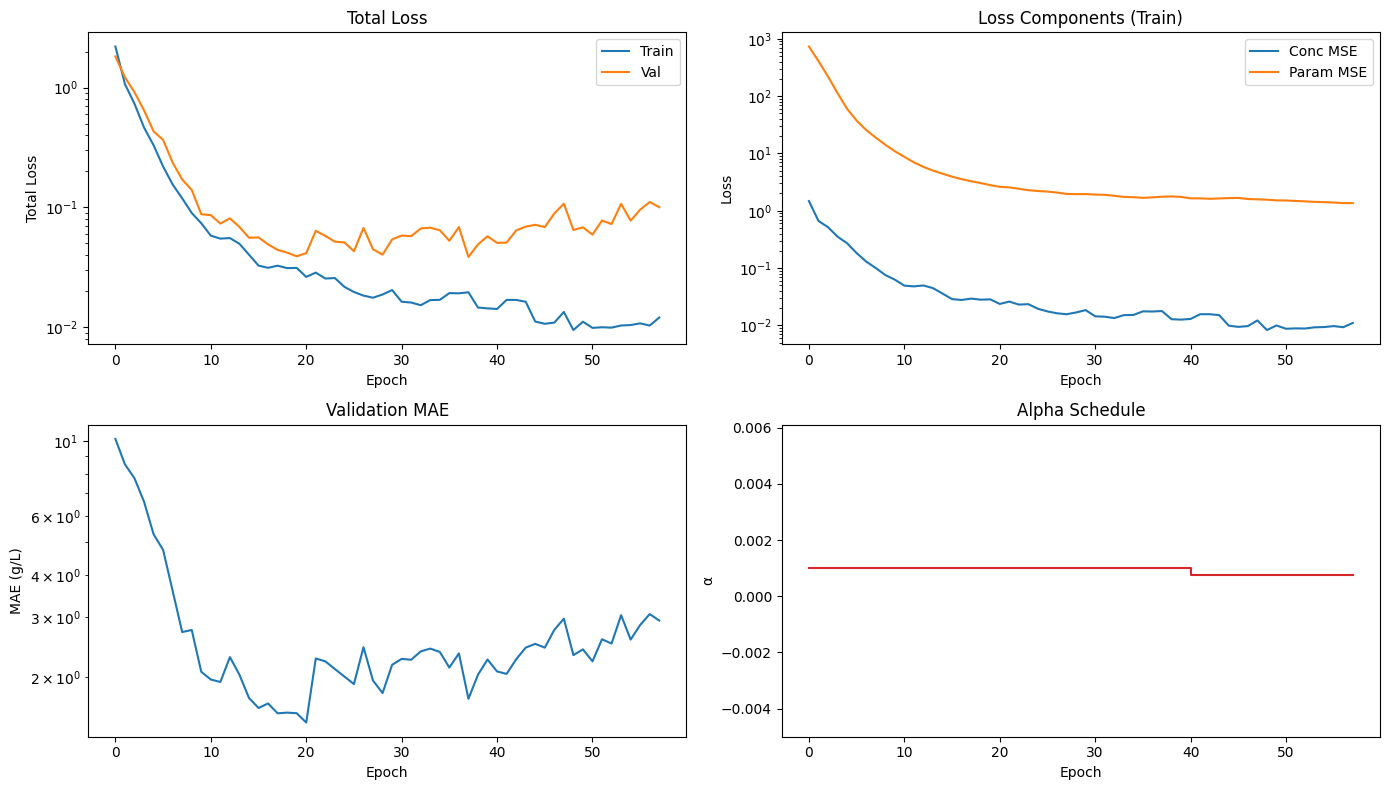

Best epoch: 38


In [ ]:
history = results["history"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Total loss
axes[0, 0].semilogy(history["train_loss"], label="Train")
axes[0, 0].semilogy(history["val_loss"], label="Val")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Total Loss")
axes[0, 0].set_title("Total Loss")
axes[0, 0].legend()

# Component losses
axes[0, 1].semilogy(history["train_conc_loss"], label="Conc MSE")
axes[0, 1].semilogy(history["train_param_loss"], label="Param MSE")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].set_title("Loss Components (Train)")
axes[0, 1].legend()

# Val MAE
axes[1, 0].semilogy(history["val_mae"])
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("MAE (g/L)")
axes[1, 0].set_title("Validation MAE")

# Alpha schedule
axes[1, 1].step(range(len(history["alpha"])), history["alpha"], where="post", color="tab:red")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("α")
axes[1, 1].set_title("Alpha Schedule")
axes[1, 1].set_ylim(-0.005, max(history["alpha"]) * 1.1 + 0.005)

plt.tight_layout()
plt.show()

print(f"Best epoch: {results['best_epoch']}")

## 5. Results Summary

In [25]:
print("=" * 50)
print("PieceLog-PatchTST Results")
print("=" * 50)
for split_name in ["train", "val", "target"]:
    metrics = results[f"{split_name}_metrics"]
    print(f"{split_name.capitalize():>7s} | MAE: {metrics['mae']:.3f} | RMSE: {metrics['rmse']:.3f}")
print("=" * 50)

PieceLog-PatchTST Results
  Train | MAE: 0.970 | RMSE: 1.223
    Val | MAE: 1.720 | RMSE: 1.966
 Target | MAE: 1.567 | RMSE: 2.051


### 5.1 Train & Validation Curve Examples

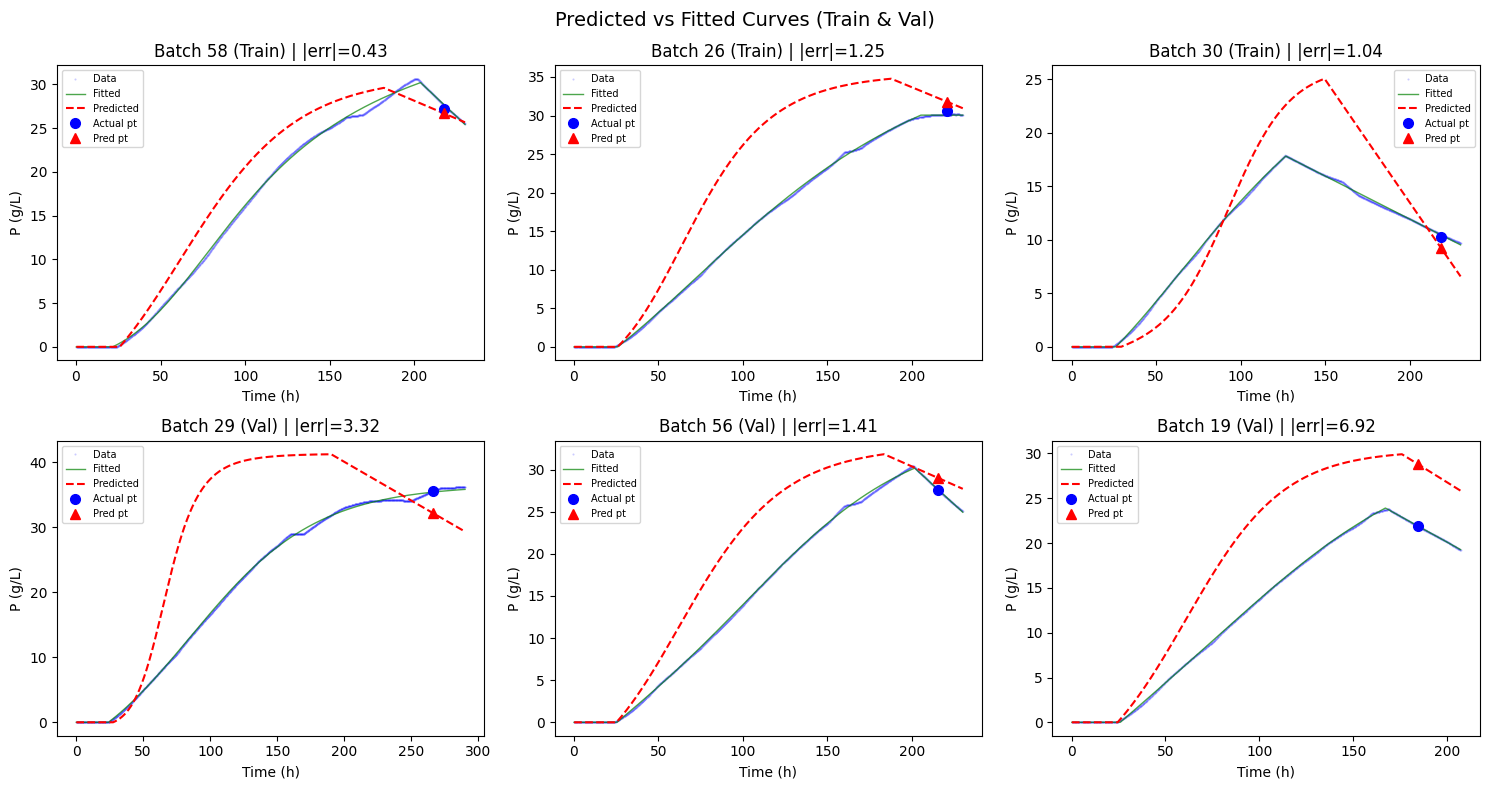

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
model.eval()

train_ds = loaders["train_dataset"]
val_ds = loaders["val_dataset"]

# Collect unique batch IDs (first 3 from each split)
train_bids = list(dict.fromkeys(s["batch_id"] for s in train_ds.samples))[:3]
val_bids = list(dict.fromkeys(s["batch_id"] for s in val_ds.samples))[:3]

for row_idx, (split_label, ds, bids) in enumerate([
    ("Train", train_ds, train_bids),
    ("Val", val_ds, val_bids),
]):
    for col_idx, bid in enumerate(bids):
        ax = axes[row_idx, col_idx]
        df = batches[bid]
        t = df["time"].values
        y_actual = df["P"].values

        # Find a sample for this batch
        sample_idx = next(
            (i for i, s in enumerate(ds.samples) if s["batch_id"] == bid), None
        )
        if sample_idx is None:
            ax.set_title(f"Batch {bid} — no sample")
            continue

        sample = ds[sample_idx]
        x_input = sample["x"].unsqueeze(0).to(device)
        t_predict = sample["t_predict"].item()
        y_conc = sample["y_conc"].item()

        with torch.no_grad():
            params_pred = model.get_parameters(x_input)
            params_np = {k: v.cpu().item() for k, v in params_pred.items()}
            P_pred = model(x_input, sample["t_predict"].unsqueeze(0).to(device)).item()

        # Curves
        y_pred_curve = piecelog_numpy(t, **params_np)
        row = fitted_params_df[fitted_params_df["batch_id"] == bid].iloc[0]
        y_fitted_curve = piecelog_numpy(t, *[row[p] for p in PARAM_NAMES])

        ax.plot(t, y_actual, "b.", alpha=0.2, markersize=1, label="Data")
        ax.plot(t, y_fitted_curve, "g-", linewidth=1, alpha=0.7, label="Fitted")
        ax.plot(t, y_pred_curve, "r--", linewidth=1.5, label="Predicted")

        # Mark prediction point
        ax.plot(t_predict, y_conc, "bo", markersize=7, label="Actual pt")
        ax.plot(t_predict, P_pred, "r^", markersize=7, label="Pred pt")

        err = abs(P_pred - y_conc)
        ax.set_title(f"Batch {bid} ({split_label}) | |err|={err:.2f}")
        ax.set_xlabel("Time (h)")
        ax.set_ylabel("P (g/L)")
        ax.legend(fontsize=7)

plt.suptitle("Predicted vs Fitted Curves (Train & Val)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Interpretability — Predicted Parameters vs Fitted

In [15]:
# Collect predicted parameters from val set
model.eval()
model = model.to(device)

all_params_pred = {p: [] for p in PARAM_NAMES}
all_params_true = {p: [] for p in PARAM_NAMES}

with torch.no_grad():
    for batch in loaders["val"]:
        x = batch["x"].to(device)
        params_pred = model.get_parameters(x)
        params_true = batch["params_fitted"]

        for i, name in enumerate(PARAM_NAMES):
            all_params_pred[name].append(params_pred[name].cpu().numpy())
            all_params_true[name].append(params_true[:, i].numpy())

for name in PARAM_NAMES:
    all_params_pred[name] = np.concatenate(all_params_pred[name])
    all_params_true[name] = np.concatenate(all_params_true[name])

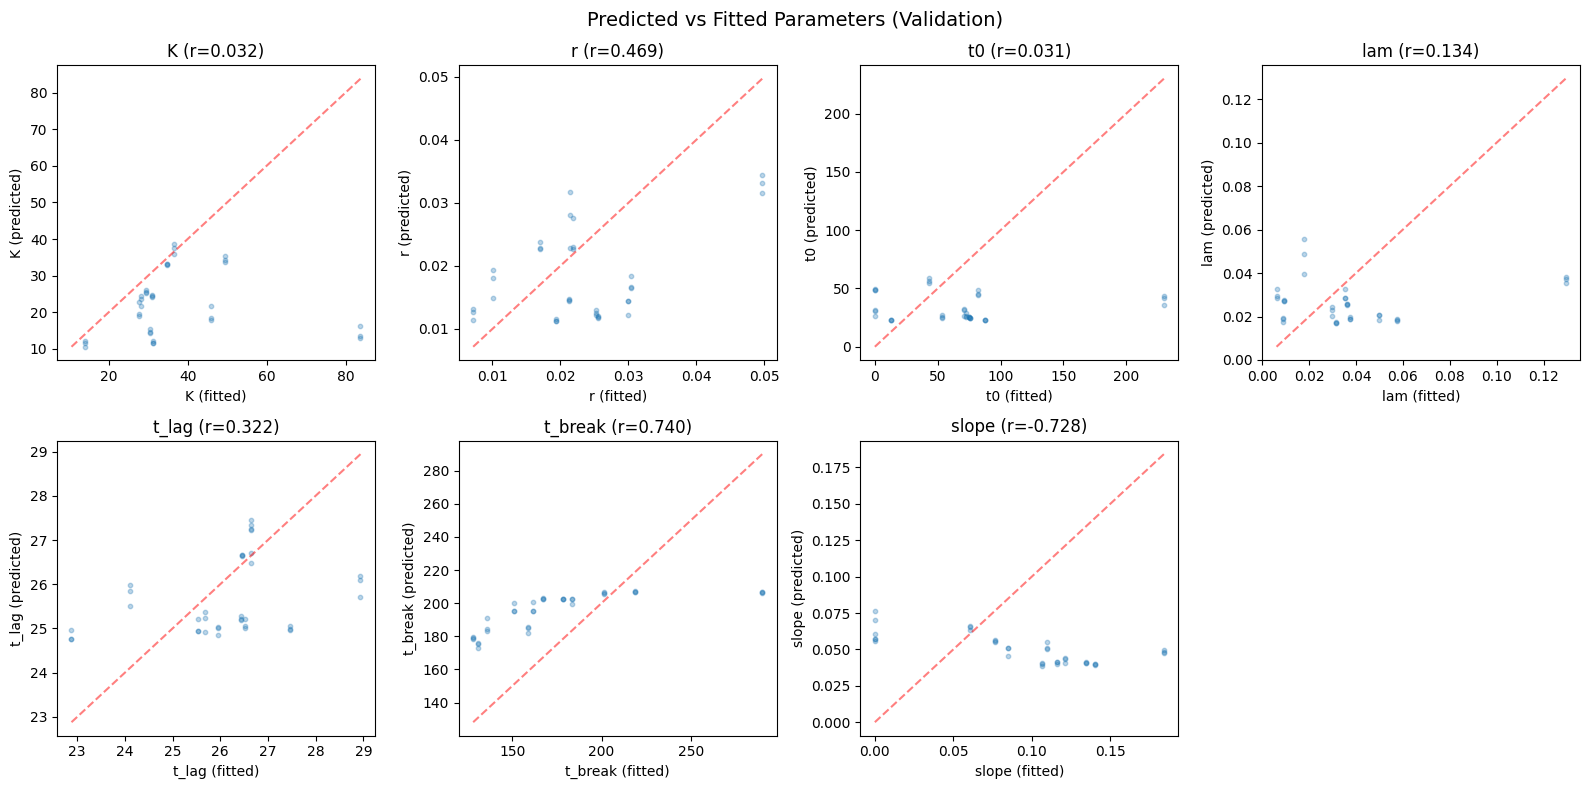

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flat

for i, name in enumerate(PARAM_NAMES):
    ax = axes[i]
    ax.scatter(all_params_true[name], all_params_pred[name], alpha=0.3, s=10)
    lims = [
        min(all_params_true[name].min(), all_params_pred[name].min()),
        max(all_params_true[name].max(), all_params_pred[name].max()),
    ]
    ax.plot(lims, lims, "r--", alpha=0.5)
    ax.set_xlabel(f"{name} (fitted)")
    ax.set_ylabel(f"{name} (predicted)")
    corr = np.corrcoef(all_params_true[name], all_params_pred[name])[0, 1]
    ax.set_title(f"{name} (r={corr:.3f})")

# Hide unused subplot
axes[7].set_visible(False)

plt.suptitle("Predicted vs Fitted Parameters (Validation)", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Predicted Curves vs Actual Data

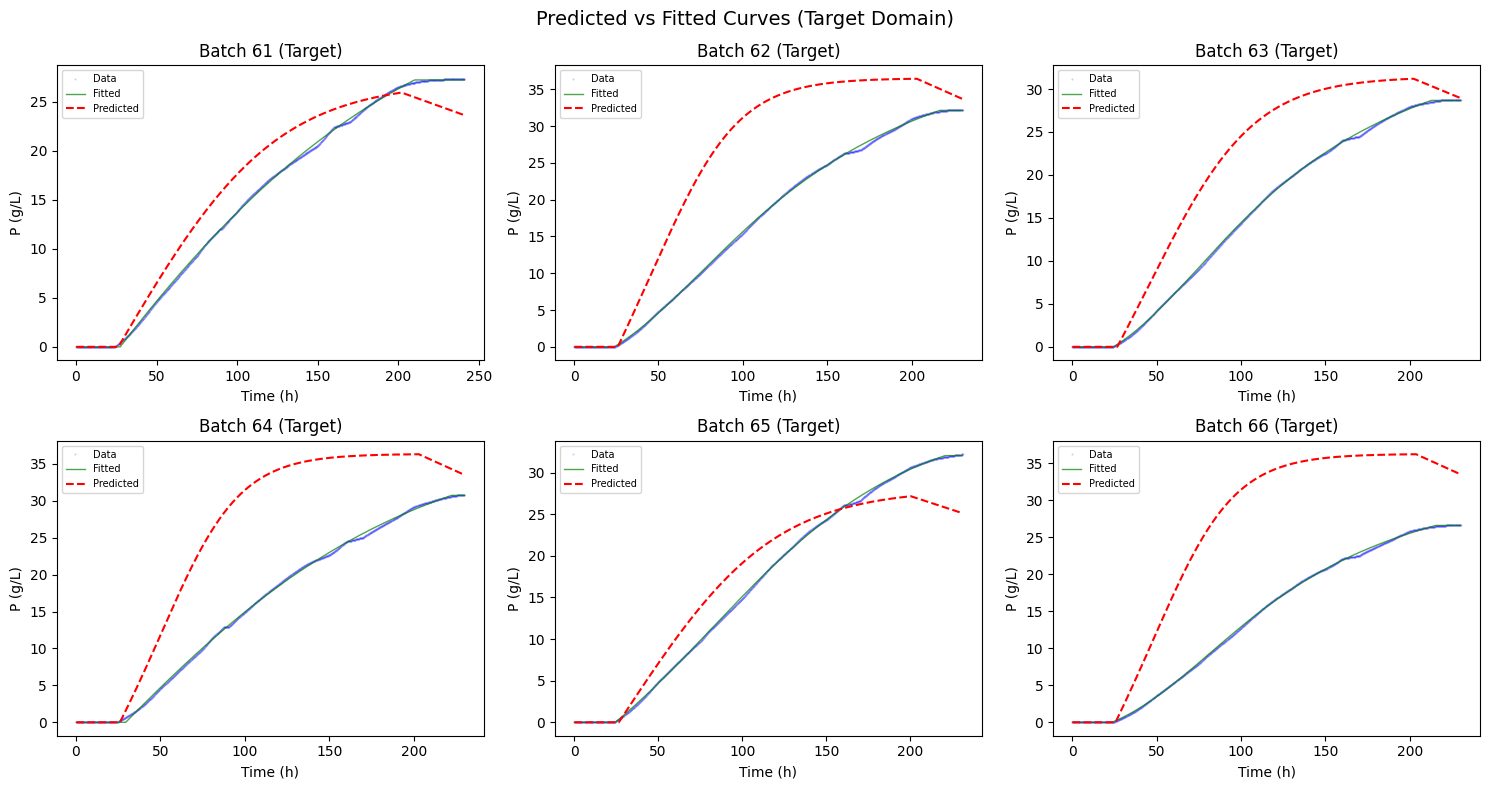

In [17]:
# Show predicted curves for a few target batches
example_target_ids = list(target_ids[:6])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

model.eval()
target_ds = loaders["target_dataset"]

for ax, bid in zip(axes.flat, example_target_ids):
    df = batches[bid]
    t = df["time"].values
    y_actual = df["P"].values

    # Find a sample for this batch
    sample_idx = next(
        (i for i, s in enumerate(target_ds.samples) if s["batch_id"] == bid),
        None,
    )
    if sample_idx is None:
        continue

    sample = target_ds[sample_idx]
    x_input = sample["x"].unsqueeze(0).to(device)

    with torch.no_grad():
        params_pred = model.get_parameters(x_input)
        params_np = {k: v.cpu().item() for k, v in params_pred.items()}

    y_pred_curve = piecelog_numpy(t, **params_np)

    # Fitted curve
    row = fitted_params_df[fitted_params_df["batch_id"] == bid].iloc[0]
    y_fitted_curve = piecelog_numpy(t, *[row[p] for p in PARAM_NAMES])

    ax.plot(t, y_actual, "b.", alpha=0.2, markersize=1, label="Data")
    ax.plot(t, y_fitted_curve, "g-", linewidth=1, alpha=0.7, label="Fitted")
    ax.plot(t, y_pred_curve, "r--", linewidth=1.5, label="Predicted")

    ax.set_title(f"Batch {bid} (Target)")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("P (g/L)")
    ax.legend(fontsize=7)

plt.suptitle("Predicted vs Fitted Curves (Target Domain)", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Horizon Analysis — MAE at Different D Values

In [18]:
# Collect per-sample predictions and horizons from target set
all_preds = []
all_targets_y = []
all_t_predict = []

model.eval()
with torch.no_grad():
    for batch in loaders["target"]:
        x = batch["x"].to(device)
        t_pred = batch["t_predict"].to(device)
        y_true = batch["y_conc"]

        P_pred = model(x, t_pred)

        all_preds.append(P_pred.cpu().numpy())
        all_targets_y.append(y_true.numpy())
        all_t_predict.append(batch["t_predict"].numpy())

all_preds = np.concatenate(all_preds)
all_targets_y = np.concatenate(all_targets_y)
all_t_predict = np.concatenate(all_t_predict)

errors = np.abs(all_preds - all_targets_y)

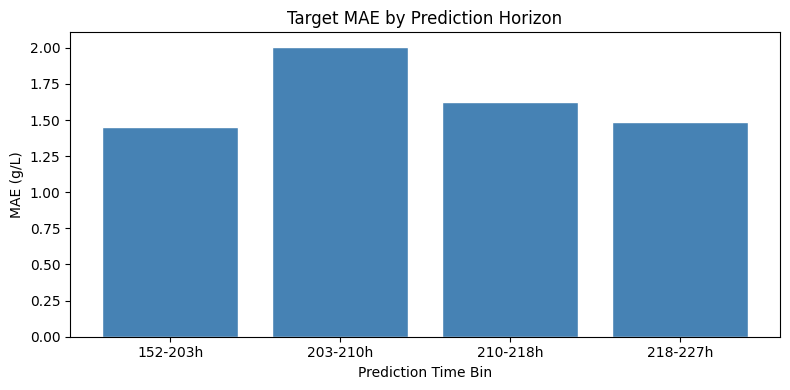

  152-203h: MAE = 1.452
  203-210h: MAE = 2.007
  210-218h: MAE = 1.628
  218-227h: MAE = 1.485


In [19]:
# Bin by t_predict ranges
bins = np.percentile(all_t_predict, [0, 25, 50, 75, 100])
bin_labels = [f"{bins[i]:.0f}-{bins[i+1]:.0f}h" for i in range(len(bins)-1)]
bin_indices = np.digitize(all_t_predict, bins[1:-1])

mae_by_bin = []
for b in range(len(bin_labels)):
    mask = bin_indices == b
    if mask.sum() > 0:
        mae_by_bin.append(errors[mask].mean())
    else:
        mae_by_bin.append(0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bin_labels, mae_by_bin, color="steelblue", edgecolor="white")
ax.set_xlabel("Prediction Time Bin")
ax.set_ylabel("MAE (g/L)")
ax.set_title("Target MAE by Prediction Horizon")
plt.tight_layout()
plt.show()

for label, mae in zip(bin_labels, mae_by_bin):
    print(f"  {label}: MAE = {mae:.3f}")